In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('plant_growth_data.csv')
df.head()

,Soil_Type,Sunlight_Hours,Water_Frequency,Fertilizer_Type,Temperature,Humidity,Growth_Milestone
0,loam,5.192294,bi-weekly,chemical,31.719602,61.591861,0
1,sandy,4.033133,weekly,organic,28.919484,52.422276,1
2,loam,8.892769,bi-weekly,none,23.179059,44.660539,0
3,loam,8.241144,bi-weekly,none,18.465886,46.433227,0
4,sandy,8.374043,bi-weekly,organic,18.128741,63.625923,0


In [3]:
df.isnull().sum()

Soil_Type           0
Sunlight_Hours      0
Water_Frequency     0
Fertilizer_Type     0
Temperature         0
Humidity            0
Growth_Milestone    0
dtype: int64

In [4]:
print(df.value_counts('Soil_Type'), '\n\n',
      df.value_counts('Water_Frequency'), '\n\n',
      df.value_counts('Fertilizer_Type'), '\n\n',
      df.value_counts('Growth_Milestone'))

Soil_Type
clay     67
sandy    64
loam     62
Name: count, dtype: int64 

 Water_Frequency
daily        74
bi-weekly    60
weekly       59
Name: count, dtype: int64 

 Fertilizer_Type
none        74
chemical    65
organic     54
Name: count, dtype: int64 

 Growth_Milestone
0    97
1    96
Name: count, dtype: int64


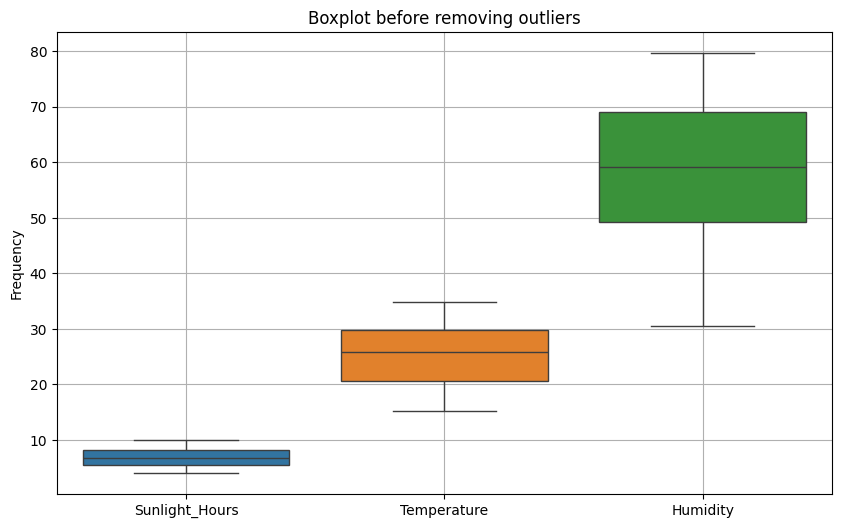

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Sunlight_Hours', 'Temperature', 'Humidity']])
plt.title('Boxplot before removing outliers')
plt.ylabel('Frequency')
plt.xticks(range(3), df[['Sunlight_Hours', 'Temperature', 'Humidity']])
plt.grid(True)
plt.show()

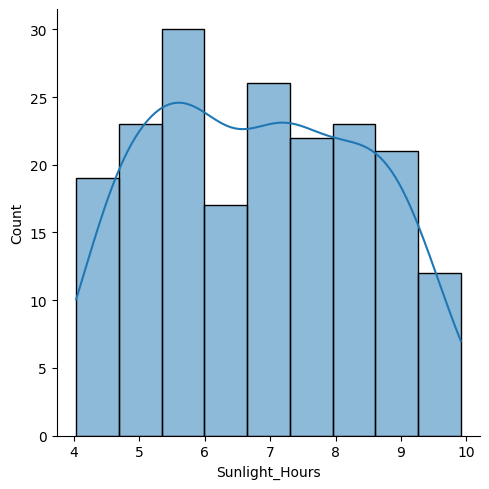

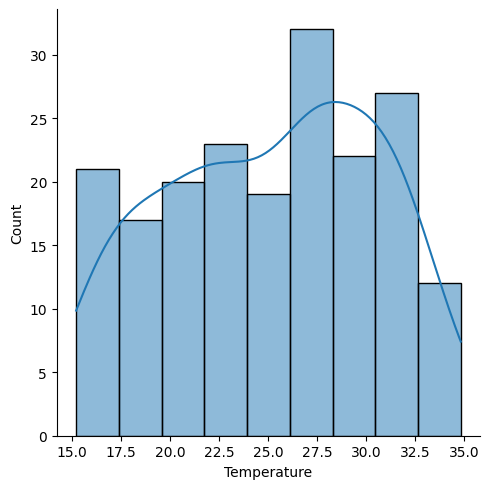

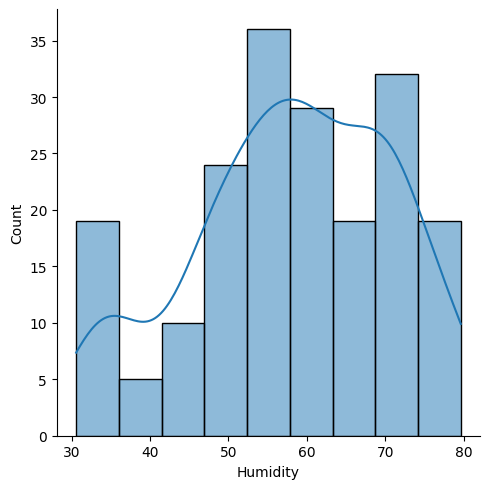

In [6]:
sns.displot(df['Sunlight_Hours'], kde=True)
sns.displot(df['Temperature'], kde=True)
sns.displot(df['Humidity'], kde=True)

In [7]:
for column in ['Soil_Type', 'Water_Frequency', 'Fertilizer_Type']:
    df[column] = pd.factorize(df[column])[0] + 1
    
df.head()

,Soil_Type,Sunlight_Hours,Water_Frequency,Fertilizer_Type,Temperature,Humidity,Growth_Milestone
0,1,5.192294,1,1,31.719602,61.591861,0
1,2,4.033133,2,2,28.919484,52.422276,1
2,1,8.892769,1,3,23.179059,44.660539,0
3,1,8.241144,1,3,18.465886,46.433227,0
4,2,8.374043,1,2,18.128741,63.625923,0


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.iloc[:, :6]
Y = df.iloc[:, 6]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=101)

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=101)
rf.fit(X_train, Y_train)

Y_pred_train = rf.predict(X_train)
Y_pred_test = rf.predict(X_test)

accuracy_train = accuracy_score(Y_train, Y_pred_train)
accuracy_test = accuracy_score(Y_test, Y_pred_test)

print('Training Accuracy : ', accuracy_train)
print('Testing Accuracy : ', accuracy_test)

print('\nClassification Report :-\n', classification_report(Y_test, Y_pred_test))
print('\nConfusion Matrix :-\n', confusion_matrix(Y_test, Y_pred_test))

Training Accuracy :  1.0
Testing Accuracy :  0.71875

Classification Report :-
               precision    recall  f1-score   support

           0       0.67      0.80      0.73        30
           1       0.79      0.65      0.71        34

    accuracy                           0.72        64
   macro avg       0.73      0.72      0.72        64
weighted avg       0.73      0.72      0.72        64


Confusion Matrix :-
 [[24  6]
 [12 22]]


In [10]:
from xgboost import XGBClassifier

xgbc = XGBClassifier(random_state=101)
xgbc.fit(X_train, Y_train)

Y_pred_train = xgbc.predict(X_train)
Y_pred_test = xgbc.predict(X_test)

accuracy_train = accuracy_score(Y_train, Y_pred_train)
accuracy_test = accuracy_score(Y_test, Y_pred_test)

print('Training Accuracy : ', accuracy_train)
print('Testing Accuracy : ', accuracy_test)

print('\nClassification Report :-\n', classification_report(Y_test, Y_pred_test))
print('\nConfusion Matrix :-\n', confusion_matrix(Y_test, Y_pred_test))

Training Accuracy :  1.0
Testing Accuracy :  0.640625

Classification Report :-
               precision    recall  f1-score   support

           0       0.59      0.73      0.66        30
           1       0.70      0.56      0.62        34

    accuracy                           0.64        64
   macro avg       0.65      0.65      0.64        64
weighted avg       0.65      0.64      0.64        64


Confusion Matrix :-
 [[22  8]
 [15 19]]


In [11]:
from xgboost import XGBRFClassifier

xgbrfc = XGBRFClassifier(random_state=101)
xgbrfc.fit(X_train, Y_train)

Y_pred_train = xgbrfc.predict(X_train)
Y_pred_test = xgbrfc.predict(X_test)

accuracy_train = accuracy_score(Y_train, Y_pred_train)
accuracy_test = accuracy_score(Y_test, Y_pred_test)

print('Training Accuracy : ', accuracy_train)
print('Testing Accuracy : ', accuracy_test)

print('\nClassification Report :-\n', classification_report(Y_test, Y_pred_test))
print('\nConfusion Matrix :-\n', confusion_matrix(Y_test, Y_pred_test))

Training Accuracy :  0.9302325581395349
Testing Accuracy :  0.671875

Classification Report :-
               precision    recall  f1-score   support

           0       0.62      0.77      0.69        30
           1       0.74      0.59      0.66        34

    accuracy                           0.67        64
   macro avg       0.68      0.68      0.67        64
weighted avg       0.68      0.67      0.67        64


Confusion Matrix :-
 [[23  7]
 [14 20]]


In [13]:
import pickle

with open('PlantGrowth_Predictor.pkl', 'wb') as file:
    pickle.dump(rf, file)
    
with open('PlantGrowth_Predictor.pkl', 'rb') as file:
    loaded_model = pickle.load(file)
    
prediction = loaded_model.predict(X_test)
print('Testing Accuracy : ', loaded_model.score(X_test, Y_test))

Testing Accuracy :  0.71875
